In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

### Задание 1. Подбор модели ###

#### *1. Известны значения фактора $\vec{x} = [~1~2~3~4~5~6~7~8~9~]^{T}$. Выпишите матрицу эксперимента X для следующих моделей:*
* $y = b_1 + b_2 x + \varepsilon$
* $y = b_1 + b_2 x + b_3 \frac{1}{x} +\varepsilon$
* $y = b_1 + b_2 x^2 + b_3 x^3 + b_4 ln(x) +\varepsilon$
####

Модель $y = b_1 + b_2 x + \varepsilon$

$ X = \begin{bmatrix} 
1 & 1  \\ 
1 & 2  \\ 
1 & 3  \\ 
1 & 4  \\ 
1 & 5  \\ 
1 & 6  \\ 
1 & 7  \\ 
1 & 8  \\ 
1 & 9  
\end{bmatrix} $

Модель $y = b_1 + b_2 x + b_3 \frac{1}{x} +\varepsilon$

$X = \begin{bmatrix} 
1 & 1 & 1   \\ 
1 & 2 & \frac{1}{2}  \\ 
1 & 3 & \frac{1}{3}  \\ 
1 & 4 & \frac{1}{4}  \\ 
1 & 5 & \frac{1}{5}  \\ 
1 & 6 & \frac{1}{6}  \\ 
1 & 7 & \frac{1}{7}  \\ 
1 & 8 & \frac{1}{8}  \\ 
1 & 9 & \frac{1}{9}  
\end{bmatrix}$

Модель $y = b_1 + b_2 x^2 + b_3 x^3 + b_4 ln(x) +\varepsilon$

$X = \begin{bmatrix} 
1 & 1^2  & 1^3  & \ln(1)  \\ 
1 & 2^2  & 2^3  & \ln(2)  \\ 
1 & 3^2  & 3^3  & \ln(3)  \\ 
1 & 4^2  & 4^3  & \ln(4)  \\ 
1 & 5^2  & 5^3  & \ln(5)  \\ 
1 & 6^2  & 6^3  & \ln(6)  \\ 
1 & 7^2  & 7^3  & \ln(7)  \\ 
1 & 8^2  & 8^3  & \ln(8)  \\ 
1 & 9^2  & 9^3  & \ln(9)  
\end{bmatrix}$

#### *2. Напишите функцию, вычисляющую оценки наименьших квадратов и критерии качества модели. С ее помощью постройте зависимость $y(x)$ по известным статистическим данным (по вариантам).* ####

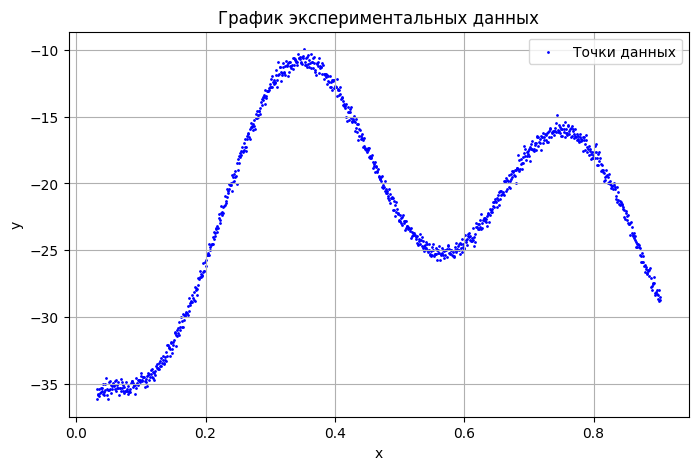

In [2]:
file_path = 'ls_variants.xls'

df = pd.read_excel(file_path, sheet_name="вар. 6")

x = df.iloc[:, 0].values.reshape(-1, 1)
y = df.iloc[:, 1].values

# Построение графика
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label="Точки данных", s=1)  # Рисуем точки
plt.xlabel("x")
plt.ylabel("y")
plt.title("График экспериментальных данных")
plt.legend()
plt.grid(True)

# Показать график
plt.show()

Лучшая модель: Ряд Фурье


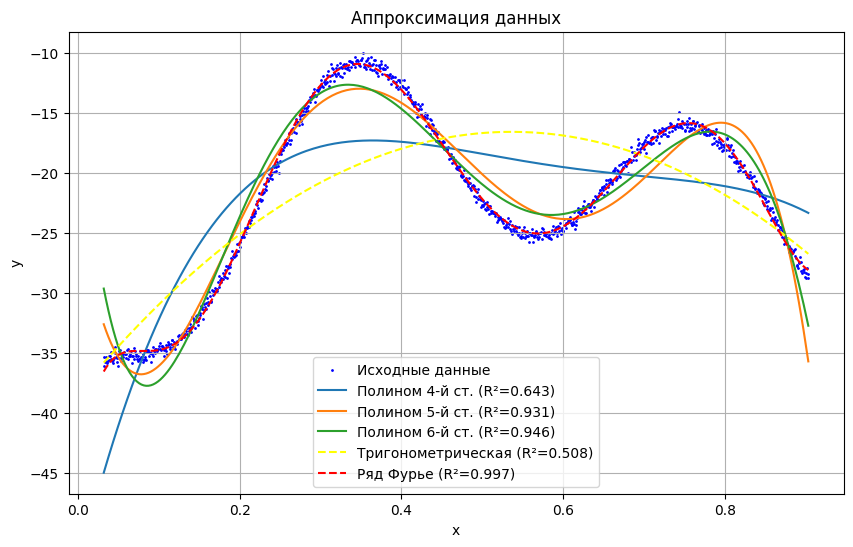

In [3]:
# Создаем диапазон x для предсказаний
x_range = np.linspace(min(x), max(x), 300).reshape(-1, 1)

# 1. Полиномиальная регрессия (степень 4–6)
best_poly_model = None
best_poly_r2 = -np.inf

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color="blue", s=1, label="Исходные данные")

for degree in range(4, 7):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(x)
    model = LinearRegression().fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    r2 = r2_score(y, y_pred)
    
    if r2 > best_poly_r2:
        best_poly_r2 = r2
        best_poly_model = (model, poly)
    
    # Строим аппроксимацию
    X_pred = poly.transform(x_range)
    y_fit = model.predict(X_pred)
    plt.plot(x_range, y_fit, label=f"Полином {degree}-й ст. (R²={r2:.3f})")

# 2. Тригонометрическая регрессия
def trig_model(x, a, b, c, d):
    return a * np.sin(b * x + c) + d

popt, _ = curve_fit(trig_model, x.ravel(), y, p0=[10, 10, 0, -20], maxfev=5000)
y_trig_pred = trig_model(x, *popt)
r2_trig = r2_score(y, y_trig_pred)

# Строим график тригонометрической модели
y_trig_fit = trig_model(x_range, *popt)
plt.plot(x_range, y_trig_fit, label=f"Тригонометрическая (R²={r2_trig:.3f})", linestyle="dashed", color='yellow')

# 3. Разложение в ряд Фурье
def fourier_series(x, *coefficients):
    result = coefficients[0]  # a0
    n = 1
    for a, b in zip(coefficients[1::2], coefficients[2::2]):
        result += a * np.sin(n * x) + b * np.cos(n * x)
        n += 1
    return result

initial_guess = [0] * 9  # a0, a1, b1, a2, b2, a3, b3, a4, b4

# Подгонка модели Фурье
popt_fourier, _ = curve_fit(fourier_series, x.ravel(), y, p0=initial_guess, maxfev=5000)
y_fourier_pred = fourier_series(x.ravel(), *popt_fourier)
r2_fourier = r2_score(y, y_fourier_pred)

# Строим график ряда Фурье
y_fourier_fit = fourier_series(x_range.ravel(), *popt_fourier)
plt.plot(x_range, y_fourier_fit, label=f"Ряд Фурье (R²={r2_fourier:.3f})", linestyle="dashed", color='red')

# Выбор лучшей модели
best_model = "Тригонометрическая" if r2_trig > best_poly_r2 and r2_trig > r2_fourier else \
             "Ряд Фурье" if r2_fourier > best_poly_r2 else \
             f"Полином {best_poly_model[1].degree}-й ст."
print(f"Лучшая модель: {best_model}")

# Оформление графика
plt.xlabel("x")
plt.ylabel("y")
plt.title("Аппроксимация данных")
plt.legend()
plt.grid(True)
plt.show()

Функция МНК

Лучшая модель: Ряд Фурье


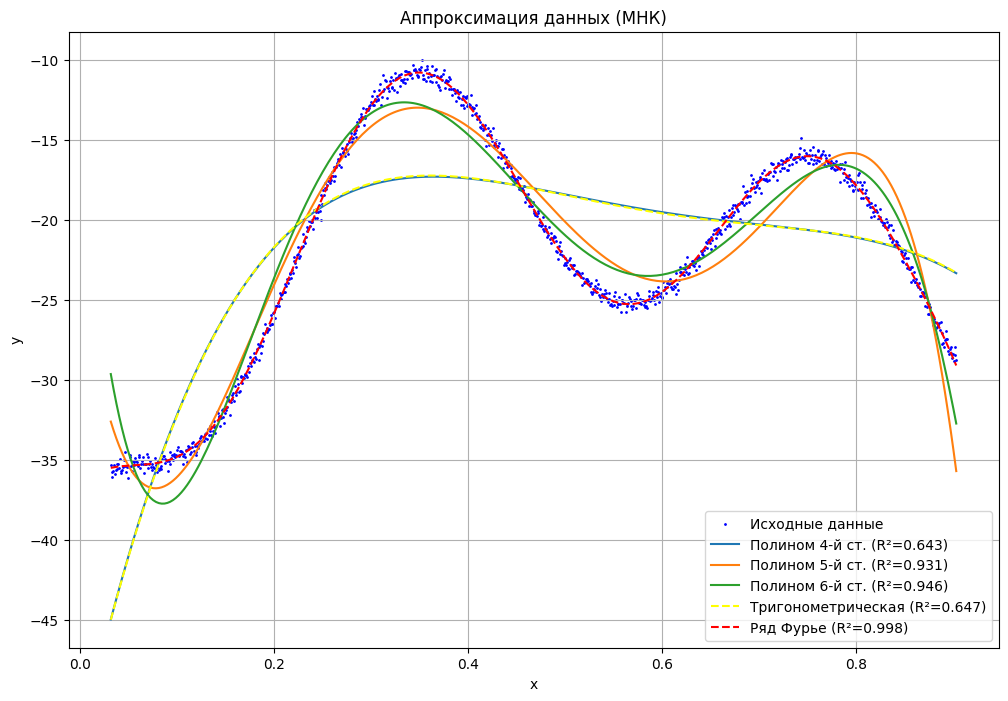

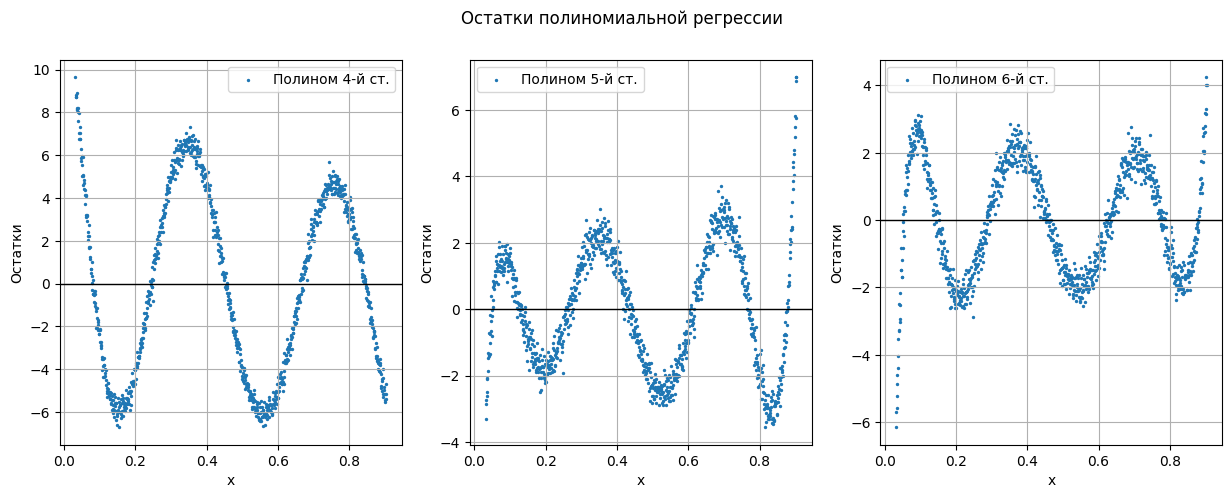

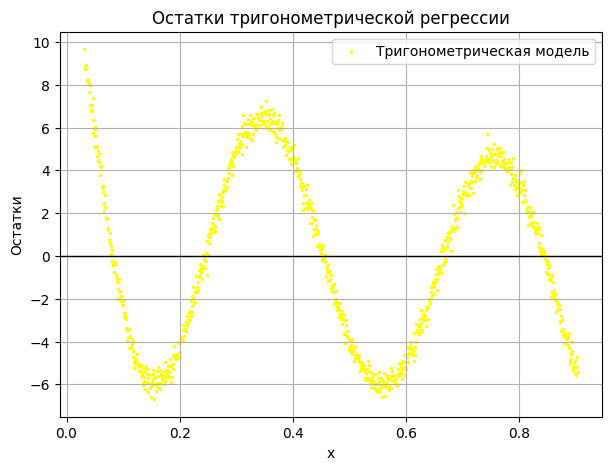

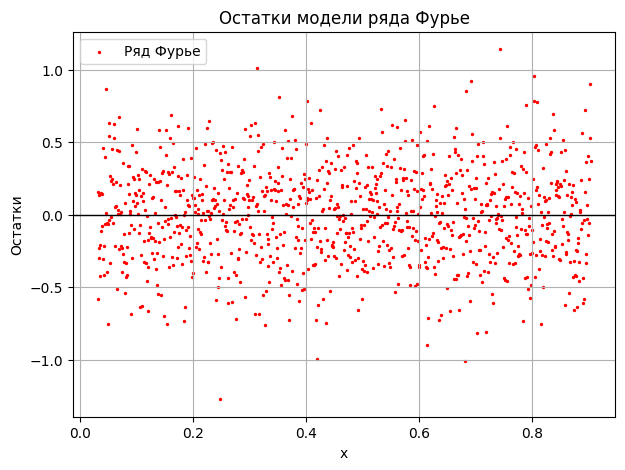

In [4]:
# Универсальная функция МНК
def fit_mnk(X, y):
    XtX = X.T @ X
    Xty = X.T @ y
    w = np.linalg.solve(XtX, Xty)
    
    def predict(X_new):
        return X_new @ w

    return w, predict

# Создаем диапазон x для предсказаний
x_range = np.linspace(min(x), max(x), 300).reshape(-1, 1)

# 1. Полиномиальная регрессия (степень 4–6)
best_poly_r2 = -np.inf
best_poly_predict = None
best_poly_degree = None

plt.figure(figsize=(12, 8))
plt.scatter(x, y, color="blue", s=1, label="Исходные данные")

residuals_poly = {}

for degree in range(4, 7):
    # Формируем полиномиальные признаки вручную
    X_poly = np.hstack([x**i for i in range(degree + 1)])
    
    # Подгонка через МНК
    w, predict_poly = fit_mnk(X_poly, y)
    
    # Предсказания и остатки
    y_pred = predict_poly(X_poly)
    residuals_poly[degree] = y - y_pred

    # R²
    r2 = r2_score(y, y_pred)
    
    if r2 > best_poly_r2:
        best_poly_r2 = r2
        best_poly_predict = predict_poly
        best_poly_degree = degree

    # Строим линию на графике
    X_poly_range = np.hstack([x_range**i for i in range(degree + 1)])
    y_fit = predict_poly(X_poly_range)
    plt.plot(x_range, y_fit, label=f"Полином {degree}-й ст. (R²={r2:.3f})")

# 2. Тригонометрическая регрессия (a*sin(b*x) + c*cos(d*x) + e)
X_trig = np.hstack([
    np.sin(x),
    np.cos(x),
    np.sin(2*x),
    np.cos(2*x),
    np.ones_like(x)  # свободный член
])

# МНК
w_trig, predict_trig = fit_mnk(X_trig, y)

# Предсказания и остатки
y_trig_pred = predict_trig(X_trig)
residuals_trig = y - y_trig_pred

# R²
r2_trig = r2_score(y, y_trig_pred)

# Строим линию на графике
X_trig_range = np.hstack([
    np.sin(x_range),
    np.cos(x_range),
    np.sin(2*x_range),
    np.cos(2*x_range),
    np.ones_like(x_range)
])
y_trig_fit = predict_trig(X_trig_range)
plt.plot(x_range, y_trig_fit, label=f"Тригонометрическая (R²={r2_trig:.3f})", linestyle="dashed", color='yellow')

# 3. Разложение в ряд Фурье (a0 + sum(a_n*sin(n*x) + b_n*cos(n*x)))
harmonics = 5
X_fourier = np.hstack([
    np.ones_like(x),  # a0
    *[np.sin(n * x) for n in range(1, harmonics+1)],
    *[np.cos(n * x) for n in range(1, harmonics+1)]
])

# МНК
w_fourier, predict_fourier = fit_mnk(X_fourier, y)

# Предсказания и остатки
y_fourier_pred = predict_fourier(X_fourier)
residuals_fourier = y - y_fourier_pred

# R²
r2_fourier = r2_score(y, y_fourier_pred)

# Строим линию на графике
X_fourier_range = np.hstack([
    np.ones_like(x_range),
    *[np.sin(n * x_range) for n in range(1, harmonics+1)],
    *[np.cos(n * x_range) for n in range(1, harmonics+1)]
])
y_fourier_fit = predict_fourier(X_fourier_range)
plt.plot(x_range, y_fourier_fit, label=f"Ряд Фурье (R²={r2_fourier:.3f})", linestyle="dashed", color='red')

# Выбор лучшей модели
best_model = "Тригонометрическая" if r2_trig > best_poly_r2 and r2_trig > r2_fourier else \
             "Ряд Фурье" if r2_fourier > best_poly_r2 else \
             f"Полином {best_poly_degree}-й ст."
print(f"Лучшая модель: {best_model}")

# Оформление графика
plt.xlabel("x")
plt.ylabel("y")
plt.title("Аппроксимация данных (МНК)")
plt.legend()
plt.grid(True)
plt.show()

# --- Графики остатков ---
plt.figure(figsize=(15, 5))

# Остатки для полиномов
for degree in range(4, 7):
    plt.subplot(1, 3, degree-3)
    plt.scatter(x, residuals_poly[degree], s=2, label=f"Полином {degree}-й ст.")
    plt.axhline(0, color='k', lw=1)
    plt.xlabel("x")
    plt.ylabel("Остатки")
    plt.legend()
    plt.grid(True)

plt.suptitle("Остатки полиномиальной регрессии")
plt.show()

# Остатки для тригонометрической модели
plt.figure(figsize=(7, 5))
plt.scatter(x, residuals_trig, s=2, color="yellow", label="Тригонометрическая модель")
plt.axhline(0, color='k', lw=1)
plt.xlabel("x")
plt.ylabel("Остатки")
plt.legend()
plt.grid(True)
plt.title("Остатки тригонометрической регрессии")
plt.show()

# Остатки для ряда Фурье
plt.figure(figsize=(7, 5))
plt.scatter(x, residuals_fourier, s=2, color="red", label="Ряд Фурье")
plt.axhline(0, color='k', lw=1)
plt.xlabel("x")
plt.ylabel("Остатки")
plt.legend()
plt.grid(True)
plt.title("Остатки модели ряда Фурье")
plt.show()


#### *3. Докажите, что оценки наименьших квадратов – несмещенные, $M\vec{b} = \vec{\beta}$* ####

Рассмотрим линейную регрессионную модель:

$\vec{Y} = X\vec{\beta} + \vec{\varepsilon},$

Оценка наименьших квадратов (МНК) для вектора параметров $\vec{b}$ вычисляется как:

$
\vec{b} = (X^T X)^{-1} X^T \vec{Y}.
$


Нам нужно показать, что $\mathbb{M}[\vec{b}] = \vec{\beta}$.

1. Подставим выражение для $\vec{Y}$ в формулу для $\vec{b}$:

   $
   \vec{b} = (X^T X)^{-1} X^T \vec{Y} = (X^T X)^{-1} X^T (X\vec{\beta} + \vec{\varepsilon}).
  $

2. Раскроем скобки:

   $
   \vec{b} = (X^T X)^{-1} X^T X \vec{\beta} + (X^T X)^{-1} X^T \vec{\varepsilon}.
  $

3. Упростим первое слагаемое:

   $
   (X^T X)^{-1} X^T X = I_p,
  $

   где $I_p$ — единичная матрица размера $p \times p$. Таким образом:

   $
   \vec{b} = \vec{\beta} + (X^T X)^{-1} X^T \vec{\varepsilon}.
  $

4. Возьмём математическое ожидание от обеих частей:

   $
   \mathbb{M}[\vec{b}] = \mathbb{M}[\vec{\beta}] + \mathbb{M}[(X^T X)^{-1} X^T \vec{\varepsilon}].
  $

5. Поскольку $\vec{\beta}$ — это константа (истинные значения параметров), то $\mathbb{M}[\vec{\beta}] = \vec{\beta}$.

6. Рассмотрим второе слагаемое:

   $
   \mathbb{M}[(X^T X)^{-1} X^T \vec{\varepsilon}] = (X^T X)^{-1} X^T \mathbb{M}[\vec{\varepsilon}].
  $

7. По условию $\mathbb{M}[\vec{\varepsilon}] = \vec{0}$, поэтому:

   $
   \mathbb{M}[(X^T X)^{-1} X^T \vec{\varepsilon}] = (X^T X)^{-1} X^T \cdot \vec{0} = \vec{0}.
  $

8. Таким образом:

   $
   \mathbb{M}[\vec{b}] = \vec{\beta} + \vec{0} = \vec{\beta}.
  $

#### *4. Докажите, что $\hat{\sigma}^2 = \frac{s^2}{n - m}$ - несмещенная оценка дисперсии остатков $M \hat{\sigma}^2 = \sigma^2$* ####

*Доказательство* 

$ \vec{Y}(\vec{x}) = \vec{x}' \vec{b} $ — прогноз модели в точке $ \vec{x} $, где неизвестен отклик $ Y(\vec{x}) $.

$ \hat{\vec{y}} \equiv X \vec{b} $ — предсказание модели в точках, для которых известно значение отклика $ \vec{Y} $.

$ \vec{e} = \vec{Y} - \hat{\vec{y}} $ — остаток.

$ S^2 = \vec{e}~'\vec{e} $ — остаточная сумма квадратов.

Предсказание:

$ X \vec{b} = X (X'X)^{-1} X' \vec{Y} = P \vec{Y} $, где  
$ P = X (X'X)^{-1} X' $.

Остатки:

$ \vec{\hat{\varepsilon}} = \vec{e} = \vec{Y} - X \vec{b} = \vec{Y} - P \vec{Y} = (E_n - P) \vec{Y} = Q \vec{Y} $,  
где  
$ Q = E_n - P $.

$ \vec{e} = Q \vec{Y} = Q (X \vec{\beta} + {\vec{\varepsilon}}) = Q X \vec{\beta} + Q \vec{\varepsilon} = 0_{n \times m} \vec{\beta} + Q \vec{\varepsilon} = Q \vec{\varepsilon} $

Рассмотрим  
$ QX = (E_n - X (X'X)^{-1} X') X = X - X (X'X)^{-1} X'X = X - X = 0_{n \times m} $.

Для дальнейшего доказательства нам понадобятся свойства операторов проектирования:

1. **Симметричность $ P' = P $**

   $ P' =  (X (X'X)^{-1} X')' =  X (X'X)^{-1} X' = P$
2. **Идемпотентность $ P^2 = P $** 

   $ P^2 = X (X'X)^{-1} X' \cdot X (X'X)^{-1} X' = X (X'X)^{-1} X' = P$

   $ Q^2 = (E_n - P)^2 = E_n - 2E_n P + P^2 = E_n - 2P + P = E_n - P = Q $

3. **$\lambda \in \{0,~1\}$ - собственные числа матрицы $P (Q)$**

   $P \vec{x} = \lambda \vec{x} | \cdot P$
   
   $P^2 \vec{x} = \lambda P \vec{x}$

   $P \vec{x} = \lambda^2 \vec{x}$

   $\lambda \vec{x} = \lambda^2 \vec{x}$

   $\lambda^2 \vec{x} = \lambda \vec{x}$

   $\lambda (\lambda - 1) \vec{x} = 0 | \div \vec{x}\neq 0$

   $\lambda (\lambda - 1) = 0$

   $\lambda_1 = 0 ; \lambda_2 = 1$

4. **$ \text{rank} (P) = \text{tr} (P) $ (для $Q$ аналогично)**

   $
   \exists A:~\det A \neq 0, ~ A^{-1} = A' ~(\text{ортогональная})
   $

   $
   A' P A = \Lambda - \text{диагонализация симметричной мартицы ортогональным преобразованием (орт. преобразование не меняет ранг)}
   $

   $
   \text{rank} (P) = \text{rank} (A' P A) = \text{rank} (\Lambda) = \sum \lambda_i \text{, где:}
   $

   $
   \Lambda - \text{диагональная матрица из собственных чисел}~P
   $

   $
   \text{tr} (P) = \text{tr} ( A \Lambda A') = \text{tr} (\Lambda) =  \sum \lambda_i  \text{, так как}~\text{tr} (A B) = \text{tr} (B A)
   $

   $\Rightarrow \text{rank} (P) = \text{tr} (P) $

5. $\text{rank} P = m$

   $
   \text{tr} (P) = \text{tr} (X (X'X)^{-1} X') = \text{tr} ((X'X)^{-1} X'X) = \text{tr} (E_m) = m \Rightarrow \text{rank} P = m
   $

6. $ \text{tr} (Q) = \text{tr} (E_n - P) = n - m \Rightarrow \text{rank} (Q) = n - m $

*Итого:*

$
M \hat{S}^2 \stackrel{опр}{=} M \vec{e}~' \vec{e} \stackrel{(1)}{=} M \vec{\varepsilon}~' Q'Q \vec{\varepsilon} \stackrel{симм.}{=} M \vec{\varepsilon}~' QQ \vec{\varepsilon} = M \vec{\varepsilon}~' Q^2 \vec{\varepsilon} \stackrel{идемп.}{=} M \vec{\varepsilon}~' Q \vec{\varepsilon} = M\left[\sum_{i=1}^{n} \sum_{j=1}^{n} q_{ij}\varepsilon_i \varepsilon_j\right] = \sum_{i=1}^{n} \sum_{j=1}^{n} q_{ij} \cdot M\varepsilon_i \varepsilon_j = \sigma^2 \sum_{i=1}^{n} q_{ii} = \sigma^2 {tr} (Q) = \sigma^2 (n-m)
$
$
\Rightarrow \hat{\sigma}^2 = \frac{\hat{S}^2}{n-m}
$

$
\vec{\varepsilon} \in \left(\vec{0}, \sigma^2 E_n\right) \Rightarrow M\varepsilon_i \varepsilon_j = \begin{cases} \sigma^2 &i=j \\ 0 & i \neq j\end{cases}
$


#### *5. Докажите, что остатки ортогональны факторам, $\vec{e}~'\vec{x_j} = 0$* ####

*Доказательство:*

$
\vec{e}~'\vec{x_j} = (Q \vec{Y})~'\vec{x_j} = \vec{Y}' Q' \vec{x_j} = \vec{Y}' Q \vec{x_j} = \vec{Y}' (E_n - P) \vec{x_j} = (\vec{Y}' - \vec{Y}'P) \vec{x_j} = \vec{Y}'\vec{x_j} - \vec{Y}'P \vec{x_j} = \vec{Y}'\vec{x_j} - \vec{Y}'\vec{x_j} = 0
$

Здесь использовали свойство оператора проектирования $P \vec{x_j} = \vec{x_j} \quad \forall \vec{x_j} \in \Omega$

Это связано с тем, что $\lambda \in \{0, 1\}$, где собственнные числа 1 ссотвествуют подпространству, на которое проектирует $P$, а собственнные числа 0 ссотвествуют ортогональному дополнению

#### *6. Докажите, что если в модель включена константа (свободный член), то остатки имеют нулевое среднее значение, $\overline{e} = \frac{1}{n}\sum_{i=1}^{n} e_i = 0$* ####

Поскольку можель включает свобоодный член, то первый столбец матрицы $X$ состоит из 1. 

Из 5 задания знаем, что остатки ортогональны факторам $\vec{e}~'\vec{x_j} = 0 ~~ \forall j$, в частности, первому столбцу $X_1$ (столбец из 1): 

$\sum_{i=1}^{n} e_i = 0~\Rightarrow~\overline{e} = \frac{1}{n}\sum_{i=1}^{n} e_i = 0$